# 🧨 Diffusion Models with PyTorch
A Tiny UNet Learns to Denoise MNIST
by Tarun Reddy Nukala (@ntreddy)

👉 This notebook demonstrates how diffusion models work, using a simple U-Net to denoise MNIST images from random noise.

In [ ]:
# Install Requirements
# Setup for PyTorch Diffusion Demo
# Install required packages if not already installed

%pip install --upgrade pip
%pip install torch torchvision matplotlib numpy

In [1]:
# Imports + Setup

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

from diffusion import get_noise_schedule, q_sample, add_noise
from model import UNet

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Running on:", device)

Running on: mps


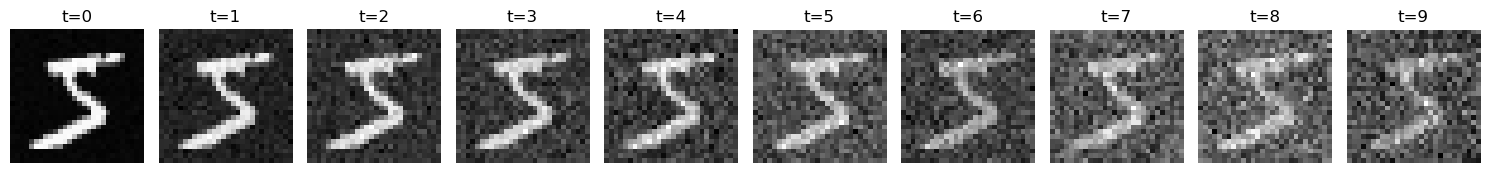

In [2]:
# Load Sample + Visualize Noise

# Load one MNIST digit and show how noise is added
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
x_start, _ = mnist[0]
x_start = x_start.unsqueeze(0)

T = 10  # Number of noise steps 

# Generate noisy images for each timestep
betas = get_noise_schedule(T).to(x_start.device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
noisy_imgs = []
for i in range(T):
    t = torch.tensor([i], device=x_start.device)
    noise = torch.randn_like(x_start)
    noisy_img = q_sample(x_start, t, noise, alphas_cumprod)
    noisy_imgs.append(noisy_img)

fig, axs = plt.subplots(1, T, figsize=(15, 2))
for i in range(T):
    axs[i].imshow(noisy_imgs[i].squeeze().detach().cpu().numpy(), cmap="gray")
    axs[i].axis("off")
    axs[i].set_title(f"t={i}")
plt.tight_layout()
plt.show()

In [ ]:
# Training on Subset

# Use a smaller dataset for quick training
# subset_indices = list(range(10000)) # Use first 10000 samples
# subset = Subset(mnist, subset_indices)
# dataloader = DataLoader(subset, batch_size=64, shuffle=True)

# Full MNIST dataset
dataloader = DataLoader(
    datasets.MNIST(root="./data", train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True
)

# Model setup
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

T = 100
betas = get_noise_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Training loop
epochs = 12
model.train()
for epoch in range(epochs):
    for batch_idx, (x, _) in enumerate(dataloader):
        x = x.to(device)

        # Log-distributed timestep sampling
        uniform = torch.rand(x.size(0), device=device)
        log_timesteps = (uniform.log() / torch.tensor(T).log()).clamp(min=-1)
        t = (T * (1.0 + log_timesteps)).long().clamp(0, T - 1)

        noise = torch.randn_like(x)
        x_noisy = q_sample(x, t, noise, alphas_cumprod)

        # Predict x0 directly
        pred_x0 = model(x_noisy)
        loss = criterion(pred_x0, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 40 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx} Loss: {loss.item():.4f}")

# Save the model
if not os.path.exists("models"):
    os.makedirs("models")
torch.save(model.state_dict(), "models/unet_denoiser.pth") 
print("Model saved!")

Epoch 1 Batch 0 Loss: 0.0990
Epoch 1 Batch 20 Loss: 0.0577
Epoch 1 Batch 40 Loss: 0.0433
Epoch 1 Batch 60 Loss: 0.0395
Epoch 1 Batch 80 Loss: 0.0379
Epoch 1 Batch 100 Loss: 0.0323
Epoch 1 Batch 120 Loss: 0.0353
Epoch 1 Batch 140 Loss: 0.0363
Epoch 1 Batch 160 Loss: 0.0297
Epoch 1 Batch 180 Loss: 0.0311
Epoch 1 Batch 200 Loss: 0.0291
Epoch 1 Batch 220 Loss: 0.0279
Epoch 1 Batch 240 Loss: 0.0290
Epoch 1 Batch 260 Loss: 0.0261
Epoch 1 Batch 280 Loss: 0.0306
Epoch 1 Batch 300 Loss: 0.0302
Epoch 1 Batch 320 Loss: 0.0298
Epoch 1 Batch 340 Loss: 0.0293
Epoch 1 Batch 360 Loss: 0.0284
Epoch 1 Batch 380 Loss: 0.0261
Epoch 1 Batch 400 Loss: 0.0239
Epoch 1 Batch 420 Loss: 0.0259
Epoch 1 Batch 440 Loss: 0.0269
Epoch 1 Batch 460 Loss: 0.0282
Epoch 1 Batch 480 Loss: 0.0254
Epoch 1 Batch 500 Loss: 0.0267
Epoch 1 Batch 520 Loss: 0.0286
Epoch 1 Batch 540 Loss: 0.0251
Epoch 1 Batch 560 Loss: 0.0252
Epoch 1 Batch 580 Loss: 0.0254
Epoch 1 Batch 600 Loss: 0.0222
Epoch 1 Batch 620 Loss: 0.0265
Epoch 1 Batch 

In [26]:
model = UNet().to(device)
model.load_state_dict(torch.load("models/unet_denoiser.pth", map_location=device))
model.eval()
print("Model loaded and ready")

# Sanity check
x_sample, _ = mnist[1]
x_sample = x_sample.unsqueeze(0).to(device)
with torch.no_grad():
    x_out = model(x_sample)
print("Sample min/max:", x_sample.min().item(), x_sample.max().item())
print("Model output min/max:", x_out.min().item(), x_out.max().item())

Model loaded and ready
Sample min/max: 0.0 1.0
Model output min/max: -0.02923986315727234 1.0054689645767212


Denoised min/max: 0.0 0.9858475923538208


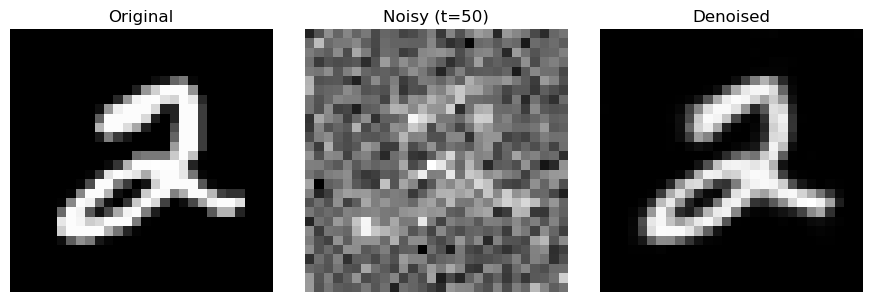

In [21]:
# Denoising Function + Visualization

def denoise_image(x_start, model, T=100, step=50):
    model.eval()
    x_start = x_start.to(device).unsqueeze(0)
    betas = get_noise_schedule(T).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    t = torch.tensor([step], device=device)
    noise = torch.randn_like(x_start)
    x_noisy = q_sample(x_start, t, noise, alphas_cumprod)

    with torch.no_grad():
        x_denoised = model(x_noisy)
        x_denoised = torch.clamp(x_denoised, 0.0, 1.0)
    
    print("Denoised min/max:", x_denoised.min().item(), x_denoised.max().item())

    imgs = [x_start.squeeze().cpu(), x_noisy.squeeze().cpu(), x_denoised.squeeze().cpu()]
    titles = ["Original", f"Noisy (t={step})", "Denoised"]
    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    for i in range(3):
        axs[i].imshow(imgs[i].numpy(), cmap="gray")
        axs[i].set_title(titles[i])
        axs[i].axis("off")
    plt.tight_layout()
    plt.show()

# Example call
sample_img, _ = mnist[5]
denoise_image(sample_img, model)

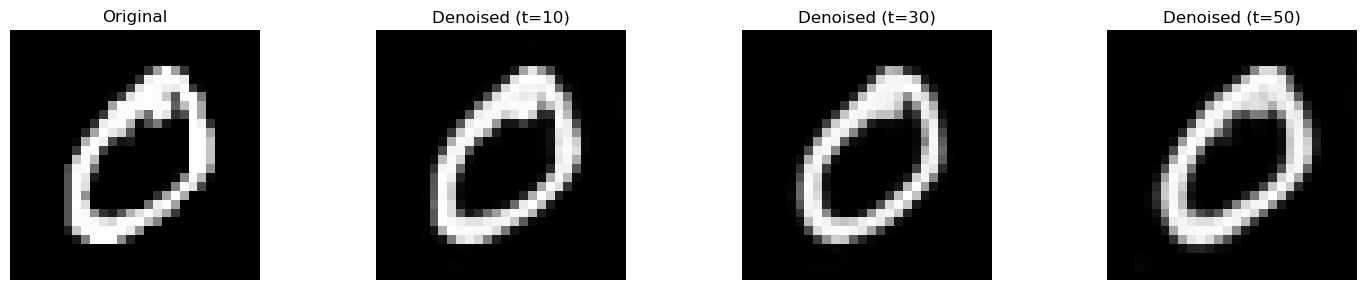

In [18]:
# Multi-timestep Denoising + Visualization

def multi_timestep_denoise(x_start, model, T=100, steps=[10, 30, 50]):
    model.eval()
    x_start = x_start.to(device).unsqueeze(0)
    betas = get_noise_schedule(T).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    fig, axs = plt.subplots(1, len(steps) + 1, figsize=(15, 3))
    axs[0].imshow(x_start.squeeze().cpu(), cmap="gray")
    axs[0].set_title("Original")
    axs[0].axis("off")

    for i, step in enumerate(steps):
        t = torch.tensor([step], device=device)
        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start, t, noise, alphas_cumprod)

        with torch.no_grad():
            # pred_noise = model(x_noisy)
            pred_x0 = model(x_noisy)    
        # x_denoised = x_noisy - pred_noise
        x_denoised = torch.clamp(pred_x0, 0.0, 1.0)

        axs[i + 1].imshow(x_denoised.squeeze().cpu(), cmap="gray")
        axs[i + 1].set_title(f"Denoised (t={step})")
        axs[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

# Run it on a fresh digit
sample_img, _ = mnist[1]
multi_timestep_denoise(sample_img, model, T=100, steps=[10, 30, 50])

In [7]:
# Denoising Function + Visualization
from torchvision.utils import save_image
import os

os.makedirs("outputs", exist_ok=True)

for i in range(5):
    fixed_img, _ = mnist[i + 40]
    x_start = fixed_img.to(device).unsqueeze(0)
    for t in [10, 30, 50]:
        betas = get_noise_schedule(100).to(device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        t_tensor = torch.tensor([t], device=device)
        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start, t_tensor, noise, alphas_cumprod)

        with torch.no_grad():
            # pred_noise = model(x_noisy)
            pred_x0 = model(x_noisy)    
        # x_denoised = x_noisy - pred_noise
        x_denoised = torch.clamp(pred_x0, 0.0, 1.0)

        filename = f"outputs/denoised_digit{i+40}_t{t}.png"
        save_image(x_denoised, filename)

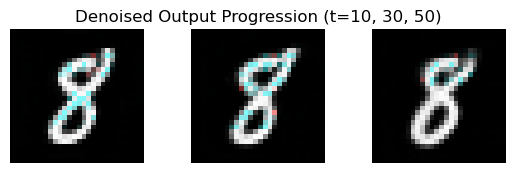

In [ ]:
# Combine and visualize denoised outputs

from PIL import Image

# Load images
img_t10 = Image.open("outputs/denoised_digit41_t10.png")
img_t30 = Image.open("outputs/denoised_digit41_t30.png")
img_t50 = Image.open("outputs/denoised_digit41_t50.png")

# Padding between images
pad = 10
width, height = img_t10.size
total_width = width * 3 + pad * 2

# Create new canvas with padding
combined = Image.new("RGB", (total_width, height), color=(255, 255, 255))
combined.paste(img_t10, (0, 0))
combined.paste(img_t30, (width + pad, 0))
combined.paste(img_t50, (2 * (width + pad), 0))

# Save and display
combined.save("outputs/denoised_progression_padded.png")

# Plot with title
import matplotlib.pyplot as plt
plt.imshow(combined)
plt.axis("off")
plt.title("Denoised Output Progression (t=10, 30, 50)")
plt.show()